In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-meas',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_meas',
        '--data_nsample', '144',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '128',
        '--nlayer_stat', '3',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.601911, valid=0.358564, test=0.345642
	validation loss decreased (inf -> 0.358564), saving model ...
	epoch 2 losses: train=0.845153, valid=0.241678, test=0.231447
	validation loss decreased (0.358564 -> 0.241678), saving model ...
	epoch 3 losses: train=0.671286, valid=0.209408, test=0.200167
	validation loss decreased (0.241678 -> 0.209408), saving model ...
	epoch 4 losses: train=0.597478, valid=0.199266, test=0.190135
	validation loss decreased (0.209408 -> 0.199266), saving model ...
	epoch 5 losses: train=0.579104, valid=0.194298, test=0.186762
	validation loss decreased (0.199266 -> 0.194298), saving model ...
	epoch 6 losses: train=0.565115, valid=0.192224, test=0.182371
	validation loss decreased (0.194298 -> 0.192224), saving model ...
	epoch 7 losses: train=0.536743, valid=0.177440, test=0.168827
	validation loss decreased (0.192224 -> 0.177440), saving model ...
	epoch 8 losses: train=0.488155, valid=0.165693, test=0.15

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

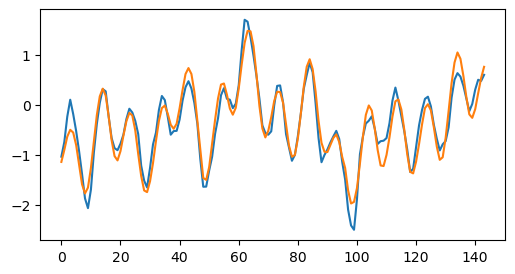

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.468378, valid=0.373956, test=0.434145
	validation loss decreased (inf -> 0.373956), saving model ...
	epoch 2 losses: train=0.411096, valid=0.364918, test=0.424348
	validation loss decreased (0.373956 -> 0.364918), saving model ...
	epoch 3 losses: train=0.405811, valid=0.358440, test=0.419621
	validation loss decreased (0.364918 -> 0.358440), saving model ...
	epoch 4 losses: train=0.400386, valid=0.343382, test=0.414203
	validation loss decreased (0.358440 -> 0.343382), saving model ...
	epoch 5 losses: train=0.386146, valid=0.324663, test=0.392091
	validation loss decreased (0.343382 -> 0.324663), saving model ...
	epoch 6 losses: train=0.368734, valid=0.318606, test=0.380209
	validation loss decreased (0.324663 -> 0.318606), saving model ...
	epoch 7 losses: train=0.359635, valid=0.306691, test=0.370468
	validation loss decreased (0.318606 -> 0.306691), saving model ...
	epoch 8 losses: train=0.355347, valid=0.304490, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

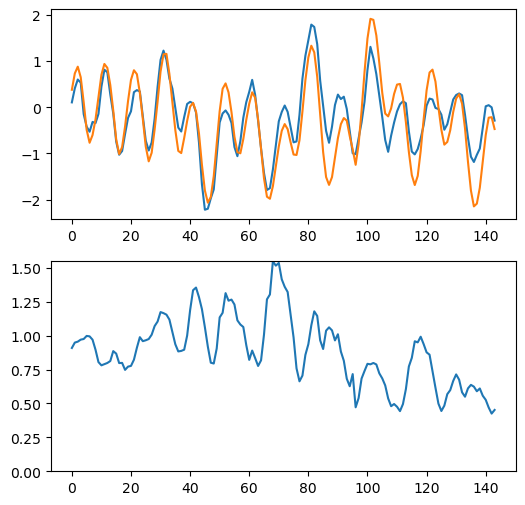

In [9]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.461444, valid=0.868237, test=0.872376
	validation loss decreased (inf -> 0.868237), saving model ...
	epoch 2 losses: train=0.846061, valid=0.562856, test=0.574039
	validation loss decreased (0.868237 -> 0.562856), saving model ...
	epoch 3 losses: train=0.663799, valid=0.494897, test=0.508444
	validation loss decreased (0.562856 -> 0.494897), saving model ...
	epoch 4 losses: train=0.615020, valid=0.450927, test=0.465355
	validation loss decreased (0.494897 -> 0.450927), saving model ...
	epoch 5 losses: train=0.555641, valid=0.412067, test=0.422949
	validation loss decreased (0.450927 -> 0.412067), saving model ...
	epoch 6 losses: train=0.498237, valid=0.375358, test=0.386937
	validation loss decreased (0.412067 -> 0.375358), saving model ...
	epoch 7 losses: train=0.449182, valid=0.345660, test=0.358223
	validation loss decreased (0.375358 -> 0.345660), saving model ...
	epoch 8 losses: train=0.413497, valid=0.342882, test=0.355

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

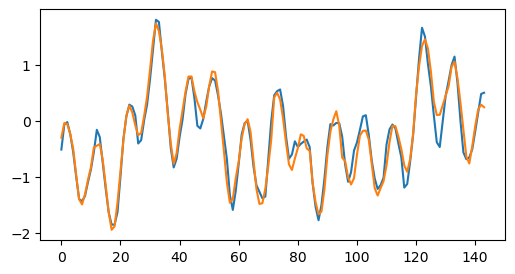

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.117937, valid=0.011565, test=0.176118
	validation loss decreased (inf -> 0.011565), saving model ...
	epoch 2 losses: train=0.065173, valid=0.202792, test=0.202853
	early stopping counter: 1 out of 30
	epoch 3 losses: train=-0.003862, valid=-0.008804, test=-0.005417
	validation loss decreased (0.011565 -> -0.008804), saving model ...
	epoch 4 losses: train=-0.116879, valid=-0.083052, test=-0.078290
	validation loss decreased (-0.008804 -> -0.083052), saving model ...
	epoch 5 losses: train=-0.163023, valid=-0.119840, test=-0.114109
	validation loss decreased (-0.083052 -> -0.119840), saving model ...
	epoch 6 losses: train=-0.186098, valid=-0.159484, test=-0.155800
	validation loss decreased (-0.119840 -> -0.159484), saving model ...
	epoch 7 losses: train=-0.252939, valid=-0.193963, test=-0.189070
	validation loss decreased (-0.159484 -> -0.193963), saving model ...
	epoch 8 losses: train=-0.304913, valid=-0.225066, test=-0.

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

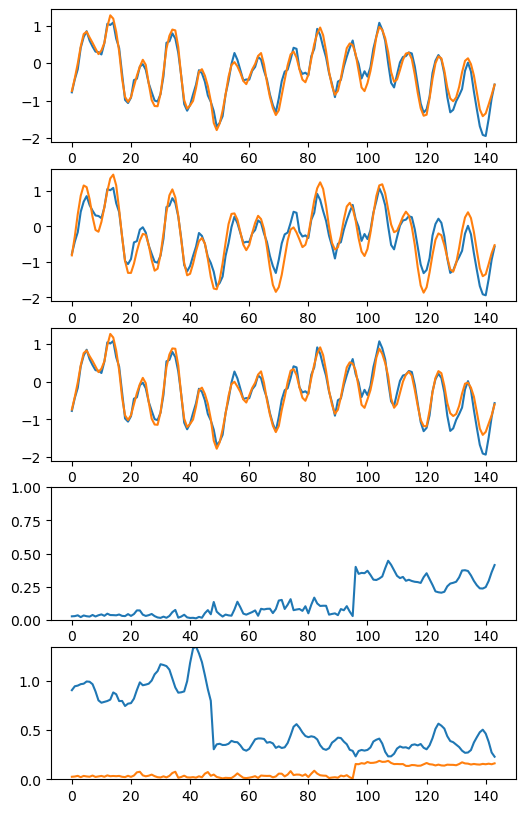

In [35]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break